In [ ]:
# Sujayv
# 24BTRAO041

# Import basic libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Set random seeds so results are more consistent between runs
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load the Heart Disease UCI dataset
data = pd.read_csv(r"C:\Users\sujay\OneDrive\Desktop\Exp4_Mlops\heart.csv")

# Fix the first column name if it contains a BOM character
data.rename(columns={data.columns[0]: "age"}, inplace=True)

# Display the first 5 rows
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Check the number of rows and columns
print("Shape of dataset:", data.shape)

# Display all column names
print("Columns:", data.columns.tolist())

Shape of dataset: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [5]:
# Display information about the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
# Display statistical summary of numerical columns
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
# Check the number of missing values in each column
print("Missing values:")
print(data.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [8]:
# Check the number of patients with and without heart disease
print(data["target"].value_counts())

target
1    165
0    138
Name: count, dtype: int64


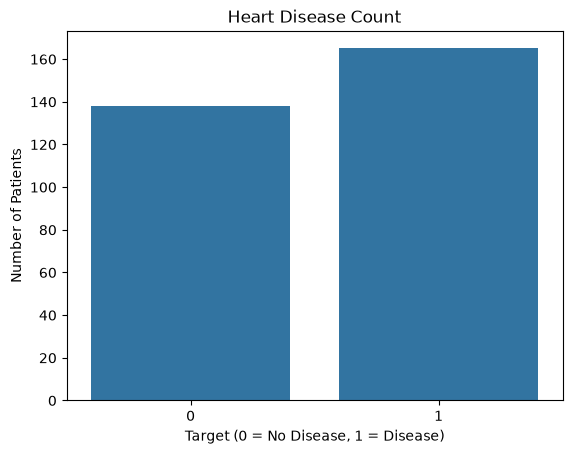

In [9]:
# Plot the number of patients with and without heart disease
sns.countplot(x="target", data=data)

plt.title("Heart Disease Count")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.show()

In [10]:
# X contains the input features
X = data.drop("target", axis=1)

# y contains the target variable
y = data["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (303, 13)
Target shape: (303,)


In [11]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (242, 13)
Testing data size: (61, 13)


In [12]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler only on training data
X_train = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [13]:
# Function to build a neural network model
def build_model(units1, units2, seed):

    # Set the random seed for this model
    tf.random.set_seed(seed)

    # Create the neural network
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(units1, activation="relu"),
        layers.Dense(units2, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    # Compile the model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
# Define different configurations for the three neural networks
model_settings = [
    {"units1": 16, "units2": 8, "seed": 1},
    {"units1": 32, "units2": 16, "seed": 2},
    {"units1": 8, "units2": 8, "seed": 3}
]

# Create an empty list to store the trained models
models = []

In [15]:
# Train each neural network separately
for i, setting in enumerate(model_settings):

    print("Training Model", i + 1)

    # Build the model
    model = build_model(
        setting["units1"],
        setting["units2"],
        setting["seed"]
    )

    # Train the model
    model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    # Store the trained model
    models.append(model)

print("All models trained successfully!")

Training Model 1
Training Model 2
Training Model 3
All models trained successfully!


In [16]:
# Create a list to store individual model accuracies
individual_accuracies = []

# Test every model separately
for i, model in enumerate(models):

    # Predict probabilities
    pred_prob = model.predict(X_test, verbose=0)

    # Convert probabilities into classes
    pred_label = (pred_prob > 0.5).astype(int).flatten()

    # Calculate accuracy
    acc = accuracy_score(y_test, pred_label)

    # Store accuracy
    individual_accuracies.append(acc)

    print("Model", i + 1, "Accuracy:", round(acc * 100, 2), "%")

Model 1 Accuracy: 80.33 %
Model 2 Accuracy: 78.69 %
Model 3 Accuracy: 81.97 %


In [17]:
# Create a list to store predictions from all models
all_predictions = []

# Generate predictions from every trained model
for model in models:

    # Get predicted probabilities
    pred_prob = model.predict(X_test, verbose=0)

    # Store predictions
    all_predictions.append(pred_prob.flatten())

# Convert predictions into a NumPy array
all_predictions = np.array(all_predictions)

print("Prediction shape:", all_predictions.shape)

Prediction shape: (3, 61)


In [18]:
# Calculate the average probability from all three models
ensemble_prob = np.mean(all_predictions, axis=0)

# Convert the average probability into class 0 or 1
ensemble_pred = (ensemble_prob > 0.5).astype(int)

print("Ensemble prediction completed.")

Ensemble prediction completed.


In [19]:
# Calculate the accuracy of the ensemble model
ensemble_acc = accuracy_score(
    y_test,
    ensemble_pred
)

print(
    "Ensemble Model Accuracy:",
    round(ensemble_acc * 100, 2),
    "%"
)

Ensemble Model Accuracy: 80.33 %


In [20]:
# Store the accuracy of all models
results = {}

for i, acc in enumerate(individual_accuracies):
    results["Model " + str(i + 1)] = acc

# Add ensemble accuracy
results["Ensemble (Average)"] = ensemble_acc

# Display accuracy comparison
print("Accuracy Comparison:")

for name, acc in results.items():
    print(name, ":", round(acc * 100, 2), "%")

Accuracy Comparison:
Model 1 : 80.33 %
Model 2 : 78.69 %
Model 3 : 81.97 %
Ensemble (Average) : 80.33 %


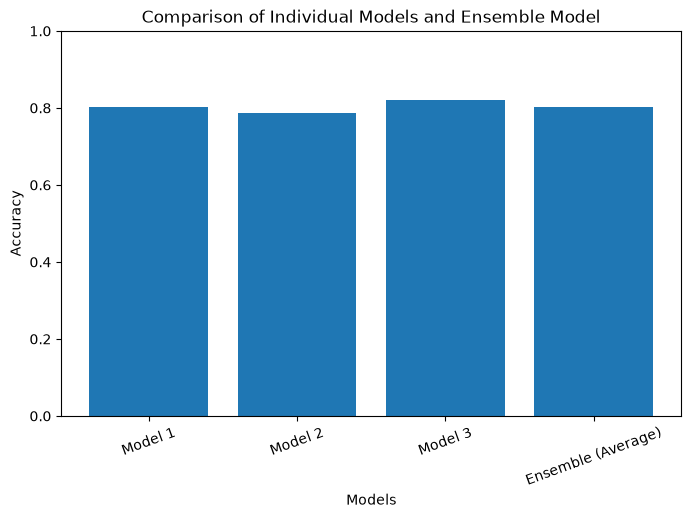

In [21]:
# Plot accuracy comparison of individual models and ensemble
plt.figure(figsize=(8, 5))

plt.bar(
    results.keys(),
    results.values()
)

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Comparison of Individual Models and Ensemble Model")

plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()

In [22]:
# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    ensemble_pred
)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20  8]
 [ 4 29]]


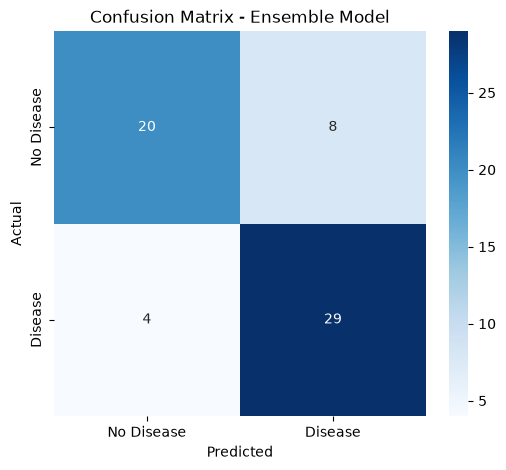

In [23]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble Model")

plt.show()

In [24]:
# Generate the classification report
print("Classification Report:")

print(
    classification_report(
        y_test,
        ensemble_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [25]:
# Display the final accuracy of all models
print("Final Results:")

for name, acc in results.items():
    print(
        name,
        ":",
        round(acc * 100, 2),
        "%"
    )

print("\nExperiment completed successfully!")

Final Results:
Model 1 : 80.33 %
Model 2 : 78.69 %
Model 3 : 81.97 %
Ensemble (Average) : 80.33 %

Experiment completed successfully!
